In [ ]:
# Introduction:

# This document provides structured comments, explanations, and reader guidance for all notebook sections in the fairness-aware recommender system project. The purpose is to help readers fully understand:

   # (A) The logic of the recommendation pipeline
   # (B) The role of fairness-aware re-ranking
   # (C) The meaning of evaluation metrics
   # (D) The purpose of experiments and visualizations
   # (E) The fairness vs accuracy trade-offs
   # (F) The optimization and robustness analysis

In [ ]:
## Phase 1 — Project Setup & Deep Understanding

In [ ]:
# Section 1: Data Loading and Preprocessing
# Cells 1-10

# Purpose:

# These cells load the MovieLens datasets, import required Python libraries, define dataset paths, and preprocess user/movie/rating information.

# What they do:

    # (A) Import libraries such as pandas, numpy, matplotlib, sklearn, and scipy.
    # (B) Load users, movies, and ratings datasets.
    # (C) Prepare matrices and data structures required for recommendation generation.
    # (D) Convert categorical information into usable numerical formats.
    
# Why they are important:

# These cells build the foundation of the recommender system. Without preprocessing, later recommendation, fairness, and evaluation stages cannot function correctly.

In [2]:
!pip3 install pandas numpy matplotlib scikit-learn jupyter tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.6 MB/s eta 0:00:00


In [3]:
%mkdir fairness-aware-recsys
%cd fairness-aware-recsys

%mkdir data src notebooks results
%mkdir data/raw data/processed
%mkdir src/models src/fairness src/evaluation src/utils
%mkdir results/figures results/tables

/content/fairness-aware-recsys


In [4]:
%cd data/raw/

/content/fairness-aware-recsys/data/raw


In [5]:
# Download the MovieLens 100K dataset
!curl -O https://files.grouplens.org/datasets/movielens/ml-100k.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 4808k  100 4808k    0     0  6742k      0 --:--:-- --:--:-- --:--:-- 6744k


In [6]:
!unzip ml-100k.zip

Archive:  ml-100k.zip
   creating: ml-100k/
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml-100k/u.data          
  inflating: ml-100k/u.genre         
  inflating: ml-100k/u.info          
  inflating: ml-100k/u.item          
  inflating: ml-100k/u.occupation    
  inflating: ml-100k/u.user          
  inflating: ml-100k/u1.base         
  inflating: ml-100k/u1.test         
  inflating: ml-100k/u2.base         
  inflating: ml-100k/u2.test         
  inflating: ml-100k/u3.base         
  inflating: ml-100k/u3.test         
  inflating: ml-100k/u4.base         
  inflating: ml-100k/u4.test         
  inflating: ml-100k/u5.base         
  inflating: ml-100k/u5.test         
  inflating: ml-100k/ua.base         
  inflating: ml-100k/ua.test         
  inflating: ml-100k/ub.base         
  inflating: ml-100k/ub.test         


In [7]:
!ls ml-100k

allbut.pl  u1.base  u2.test  u4.base  u5.test  ub.base	u.genre  u.occupation
mku.sh	   u1.test  u3.base  u4.test  ua.base  ub.test	u.info	 u.user
README	   u2.base  u3.test  u5.base  ua.test  u.data	u.item


In [8]:
%rm ml-100k.zip

In [9]:
%ls -R data/raw


ls: cannot access 'data/raw': No such file or directory


In [10]:
# Import necessary libraries
# This section imports the essential libraries for data manipulation, numerical operations, and visualization. It also sets display options for pandas and matplotlib to enhance readability and presentation of results.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = "/content/fairness-aware-recsys/data/raw/ml-100k/"

In [ ]:
# Section 2: Train / Test Spliting
# Cells 11-18

# Purpose:

# These cells divide the ratings dataset into training and testing sets.

   # (A) What they do:
   # (B) Split interactions into train and test subsets.
   # (C) Create user–item interaction matrices.
   # (D) Prepare data for recommendation model training and evaluation.

# Why they are important:

# The split ensures recommendations are evaluated on unseen data, making performance measurements realistic and unbiased.

In [11]:
# Load the ratings data
# The ratings data is loaded from the "u.data" file, which contains user-item interactions. The data is read into a pandas DataFrame with specified column names for user ID, item ID, rating, and timestamp.
ratings = pd.read_csv(
    DATA_PATH + "u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [12]:
# Load the user data
ratings.shape

(100000, 4)

In [13]:
# Load the user data
# The user data is loaded from the "u.user" file, which contains demographic information about the users. The data is read into a pandas DataFrame with specified column names for user ID, age, gender, occupation, and zip code.
# This dataset will be crucial for analyzing fairness in the recommendation system, as it provides attributes that can be used to evaluate potential biases in the recommendations.
users = pd.read_csv(
    DATA_PATH + "u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip_code"]
)

users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [14]:
users["gender"].value_counts()

,count
gender,
M,670
F,273


In [15]:
# Load the item data
# The item data is loaded from the "u.item" file, which contains information about the movies. The data is read into a pandas DataFrame with specified column names for item ID, title, release date, video release date, IMDb URL, and genre indicators. This dataset will be essential for understanding the characteristics of the items being recommended and for analyzing any potential biases in the recommendations based on item attributes.
item_columns = [
    "item_id", "title", "release_date", "video_release_date", "imdb_url",
    "unknown", "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]

items = pd.read_csv(
    DATA_PATH + "u.item",
    sep="|",
    names=item_columns,
    encoding="latin-1"
)

items.head()

,item_id,title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [16]:
# The item dataset contains 24 columns, where the first 5 columns represent metadata about the movies (item ID, title, release date, video release date, and IMDb URL), and the remaining 19 columns are binary indicators for the presence of specific genres. Each genre column has a value of 1 if the movie belongs to that genre and 0 otherwise. This structure allows us to analyze the distribution of genres in the dataset and to evaluate any potential biases in the recommendations based on genre attributes.
genre_cols = item_columns[5:]
len(genre_cols)

19

In [17]:
# Merge the datasets
# The ratings, users, and items datasets are merged into a single DataFrame called "data". This is done by performing a series of merge operations on the common keys: "user_id" for merging ratings with users, and "item_id" for merging the resulting DataFrame with items.
data = ratings.merge(users, on="user_id").merge(items, on="item_id")

data.head()

,user_id,item_id,rating,timestamp,age,gender,occupation,zip_code,title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,49,M,writer,55105,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,39,F,executive,00000,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,25,M,writer,40206,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,28,M,technician,80525,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,47,M,educator,55113,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0


In [18]:
data.shape

(100000, 31)

In [ ]:
# Section 3: Matrix Factorization (SVD)
# Cells 19–32

# Purpose:
   # These cells implement collaborative filtering using Singular Value Decomposition (SVD).

# What they do:

# (A) Factorize the user-item matrix into latent representations.
# (B) Learn hidden preference patterns between users and movies.
# (C) Reconstruct predicted rating matrices.
# (D) Produce estimated ratings for unseen movies.

# Why they are important:
   # This forms the baseline recommendation model used throughout the project.

# About the outputs
   # The generated prediction matrix contains estimated movie preferences for every user and becomes the input for all fairness-aware experiments.

In [19]:
print("Users:", data["user_id"].nunique())
print("Movies:", data["item_id"].nunique())
print("Ratings:", len(data))
print("Genres:", len(genre_cols))

Users: 943
Movies: 1682
Ratings: 100000
Genres: 19


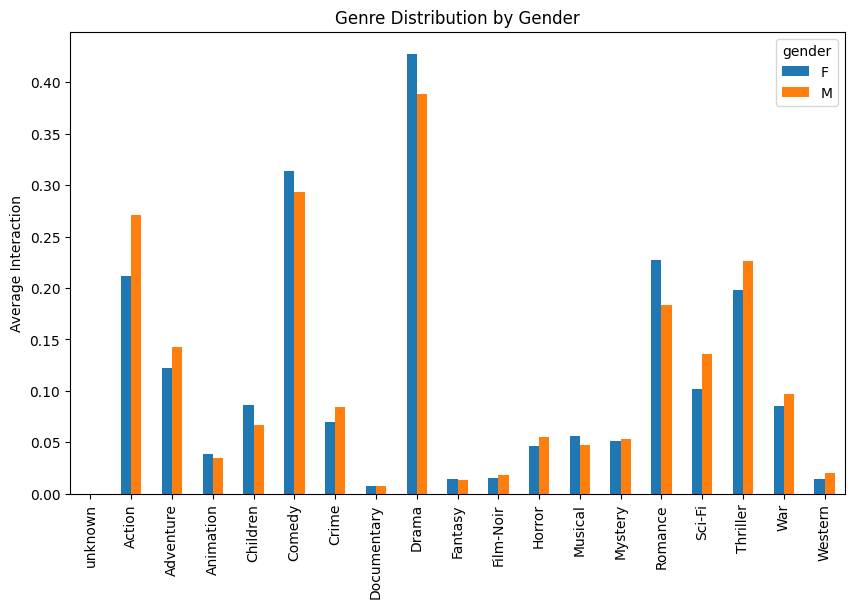

In [20]:
# Analyze genre distribution by gender
# This analysis examines the average interaction with each genre for different genders. By grouping the data by gender and calculating the mean of the genre columns, we can visualize the distribution of genre preferences across
gender_genre_dist = (
    data.groupby("gender")[genre_cols]
    .mean()
    .T
)

gender_genre_dist.plot(kind="bar")
plt.title("Genre Distribution by Gender")
plt.ylabel("Average Interaction")
plt.show()

In [21]:
# Analyze age distribution
# The age distribution of users is analyzed by creating age groups using the pd.cut function. The age groups are defined by specific bins and labels, which categorize users into different age ranges. This allows us to understand the demographic distribution of users in terms of age and to evaluate any potential biases in the recommendations based on age groups.
bins = [0, 18, 25, 35, 45, 50, 56, 100]
labels = ["<18", "18-25", "25-35", "35-45", "45-50", "50-56", "56+"]

data["age_group"] = pd.cut(data["age"], bins=bins, labels=labels)

data[["age", "age_group"]].head()

,age,age_group
0,49,45-50
1,39,35-45
2,25,18-25
3,28,25-35
4,47,45-50


/tmp/ipykernel_3728/1204710188.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("age_group")[genre_cols]


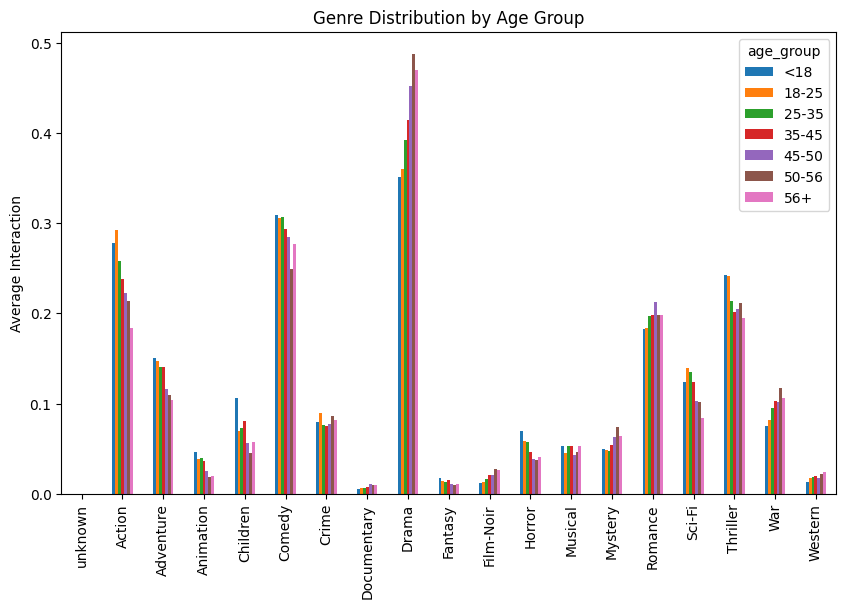

In [22]:
# Analyze genre distribution by age group
# Similar to the analysis by gender, this analysis examines the average interaction with each genre for different age groups. By grouping the data by age group and calculating the mean of the genre columns, we can visualize the distribution of genre preferences across different age demographics.
age_genre_dist = (
    data.groupby("age_group")[genre_cols]
    .mean()
    .T
)

age_genre_dist.plot(kind="bar")
plt.title("Genre Distribution by Age Group")
plt.ylabel("Average Interaction")
plt.show()

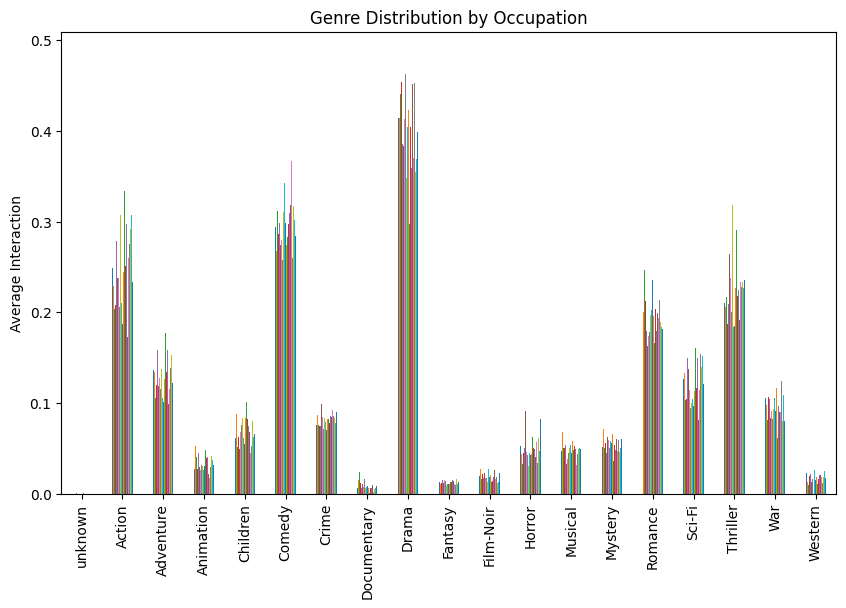

In [23]:
# Analyze genre distribution by occupation
# This analysis examines the average interaction with each genre for different occupations. By grouping the data by occupation and calculating the mean of the genre columns, we can visualize the distribution of genre preferences across different occupational groups. This can help identify any potential biases in the recommendations based on occupation and understand how different
occupation_genre_dist = (
    data.groupby("occupation")[genre_cols]
    .mean()
    .T
)

occupation_genre_dist.plot(kind="bar", legend=False)
plt.title("Genre Distribution by Occupation")
plt.ylabel("Average Interaction")
plt.show()

<Figure size 1000x600 with 0 Axes>

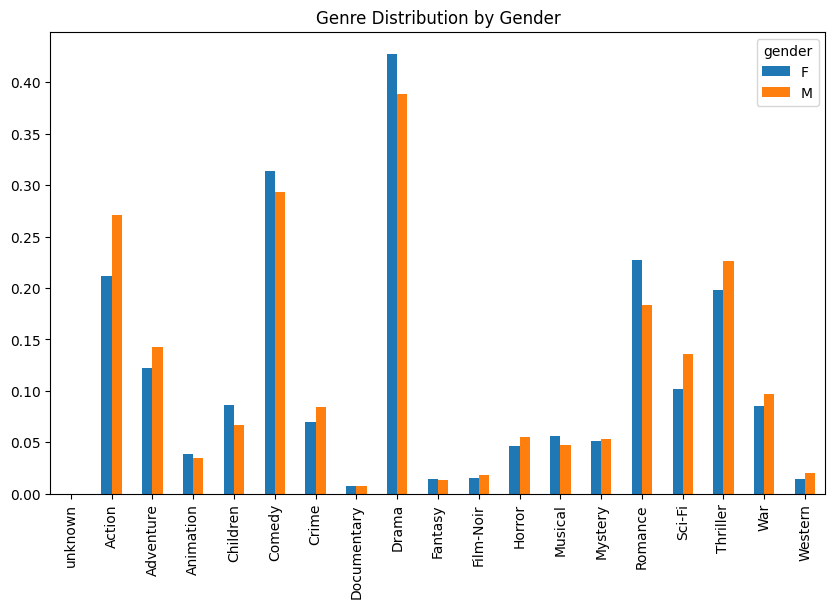

<Figure size 1000x600 with 0 Axes>

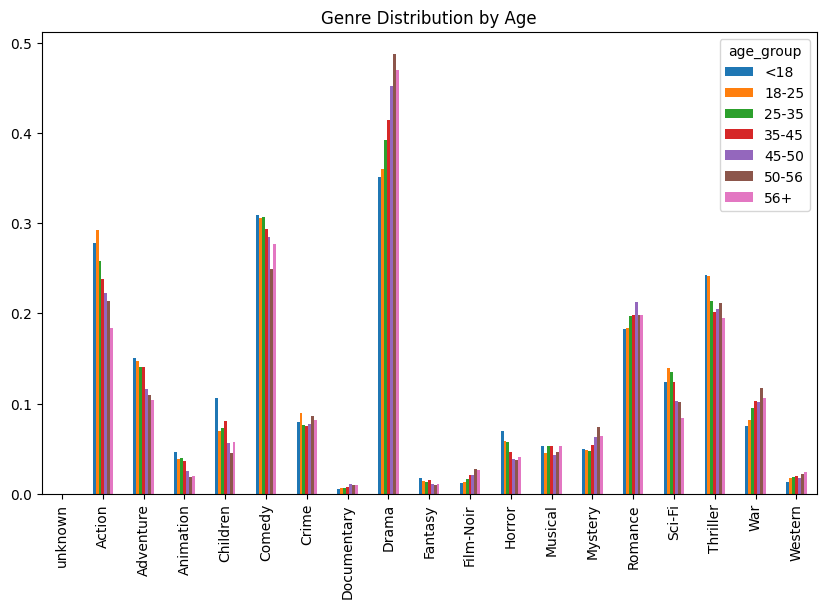

In [24]:
# Save the figures
plt.figure()
gender_genre_dist.plot(kind="bar")
plt.title("Genre Distribution by Gender")
plt.savefig("../../results/figures/gender_bias.png")

plt.figure()
age_genre_dist.plot(kind="bar")
plt.title("Genre Distribution by Age")
plt.savefig("../../results/figures/age_bias.png")

In [25]:
# Analyze average rating by gender
data.groupby("gender")["rating"].mean()

,rating
gender,
F,3.531507
M,3.529289


In [26]:
# Analyze average rating by age group
data.groupby("age_group")["rating"].mean()

/tmp/ipykernel_3728/2043771828.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("age_group")["rating"].mean()


,rating
age_group,
<18,3.552229
18-25,3.470565
25-35,3.497959
35-45,3.575259
45-50,3.567870
50-56,3.698416
56+,3.665577


In [ ]:
## Phase 2 — Baseline Recommender

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import ndcg_score
import matplotlib.pyplot as plt

In [29]:
# Set random seed for reproducibility
DATA_PATH = "ml-100k/"

ratings = pd.read_csv(
    DATA_PATH + "u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

users = pd.read_csv(
    DATA_PATH + "u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip_code"]
)

items = pd.read_csv(
    DATA_PATH + "u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [30]:
# Merge the datasets
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 80000
Test size: 20000


In [31]:
# Create user-item interaction matrix
user_item_matrix = train.pivot_table(
    index="user_id",
    columns="item_id",
    values="rating"
).fillna(0)

user_item_matrix.head()

item_id  1     2     3     4     5     6     7     8     9     10    11    \
user_id                                                                     
1         0.0   3.0   4.0   0.0   3.0   0.0   4.0   0.0   5.0   3.0   2.0   
2         4.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   4.0   
5         4.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

item_id  12    13    14    15    16    17    18    19    20    21    22    \
user_id                                                                     
1         5.0   5.0   5.0   5.0   5.0   3.0   4.0   5.0   0.0   0.0   4.0   
2         0.0   4.0   4.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
5         0.0   0.0   0.0   0.0   0.0   4.0   0.0   0.0   0.0   3.0   0.0   

item_id  23    24    25    26    27    28    29    30    31    32    33    \
user_id                                                                     
1         4.0   3.0   4.0   0.0   2.0   4.0   1.0   3.0   0.0   0.0   4.0   
2         0.0   0.0   4.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
5         0.0   0.0   3.0   0.0   0.0   0.0   4.0   0.0   0.0   0.0   0.0   

item_id  34    35    36    37    38    39    40    41    42    43    44    \
user_id                                                                     
1         2.0   1.0   2.0   2.0   0.0   4.0   3.0   2.0   5.0   4.0   5.0   
2         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
5         0.0   0.0   0.0   0.0   0.0   0.0   4.0   0.0   5.0   0.0   0.0   

item_id  45    46    47    48    49    50    51    52    53    54    55    \
user_id                                                                     
1         5.0   4.0   4.0   5.0   3.0   5.0   0.0   4.0   3.0   3.0   5.0   
2         0.0   0.0   0.0   0.0   0.0   5.0   0.0   0.0   0.0   0.0   0.0   
3         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
5         0.0   0.0   0.0   0.0   0.0   4.0   0.0   0.0   0.0   0.0   0.0   

item_id  56    57    58    59    60    61    62    63    64    65    66    \
user_id                                                                     
1         4.0   5.0   0.0   5.0   5.0   4.0   3.0   0.0   0.0   4.0   0.0   
2         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
5         0.0   0.0   0.0   0.0   0.0   0.0   4.0   0.0   0.0   0.0   1.0   

item_id  67    68    69    70    71    72    73    74    75    76    77    \
user_id                                                                     
1         3.0   0.0   3.0   3.0   3.0   4.0   3.0   1.0   4.0   4.0   0.0   
2         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
5         0.0   0.0   1.0   4.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

item_id  78    79    80    81    82    83    84    85    86    87    88    \
user_id                                                                     
1         0.0   4.0   0.0   5.0   0.0   3.0   4.0   3.0   5.0   5.

In [32]:
# Perform matrix factorization using Singular Value Decomposition (SVD)
from scipy.sparse.linalg import svds

matrix = user_item_matrix.values

U, sigma, Vt = svds(matrix, k=20)

sigma = np.diag(sigma)

predicted_ratings = np.dot(np.dot(U, sigma), Vt)

pred_df = pd.DataFrame(
    predicted_ratings,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

pred_df.head()

item_id      1         2         3         4         5         6         7     \
user_id                                                                         
1        2.034079  1.605369  1.320677  1.576579  0.244763  0.548745  4.187188   
2        1.604391 -0.170647  0.052402  0.336442 -0.165959  0.288538  1.456959   
3       -0.162863 -0.096675  0.131647  0.062012  0.024779  0.012321 -0.096753   
4        0.201246 -0.258105  0.068799  0.114065  0.002745 -0.083809  0.083956   
5        3.171150  0.877180  0.267670  0.917664  0.223504 -0.138021  2.721578   

item_id      8         9         10        11        12        13        14    \
user_id                                                                         
1        2.015903  2.085103  2.323837  2.787134  3.227351  2.934619  3.668952   
2        0.124899  2.062772  0.529087  0.076611 -0.001527  1.527234  1.606652   
3        0.256890 -0.181692  0.012022  0.433741  0.386937 -0.050686 -0.049222   
4       -0.155689 -0.239697  0.033493  0.080111  0.215196 -0.149055 -0.165568   
5        0.995366 -0.111860  0.080321 -0.411053  0.590564  0.972063  0.014071   

item_id      15        16        17        18        19        20        21    \
user_id                                                                         
1        0.959293  1.489553  1.287189  0.324102  1.640447  2.145028  0.115551   
2        1.543828  0.343244 -0.148154  0.024780  1.202800  0.578554  0.134376   
3       -0.262031 -0.003017  0.080299  0.015783 -0.148464  0.044405  0.001456   
4        0.093854  0.007471 -0.026252 -0.022197 -0.220733 -0.217667 -0.089082   
5        0.285376  0.132290  0.606338 -0.095496  0.254703 -0.020891  1.022355   

item_id      22        23        24        25        26        27        28    \
user_id                                                                         
1        2.884823  1.454968  2.643897  1.434461  1.082757  1.049767  1.877547   
2        0.179721 -0.400078  0.151723  1.552806  0.391840 -0.197024 -0.470231   
3        0.140327  0.471714  0.109866 -0.266059 -0.000039  0.075242  0.271353   
4        0.572328  0.208816 -0.056815  0.082976  0.080647 -0.063153  0.311642   
5       -0.155244 -0.202123  1.044236  1.340852 -0.097251  0.051014  1.333215   

item_id      29        30        31        32        33        34        35    \
user_id                                                                         
1        0.723465  0.933910  1.416297  1.259238  2.066912  0.132160 -0.120322   
2       -0.094018 -0.241194 -0.245104 -0.172253 -0.341725  0.003023 -0.010346   
3       -0.003830  0.075199  0.037695  0.220085  0.128959  0.001441  0.018410   
4       -0.091706 -0.094449  0.076926 -0.069506  0.056929 -0.016326  0.013341   
5        1.107327 -0.202042 -0.017722  0.216775  0.511660  0.064581  0.082509   

item_id      36        37        38        39        40        41        42    \
user_id                                                                         
1        0.077447  0.200138  0.255129  0.886501  0.088079  0.268708  2.947989   
2       -0.008994 -0.071544 -0.068736 -0.169567  0.214907 -0.127909 -0.130763   
3       -0.003092  0.035845  0.043936  0.075300 -0.017800  0.089427  0.129117   
4       -0.043140 -0.014194 -0.158759  0.081353 -0.060294  0.092559  0.136992   
5       -0.076823  0.092977  0.771066  0.335676  0.743976  0.289317  0.688788   

item_id      43        44        45        46        47        48        49    \
user_id                                                                         
1        0.559718  0.121087  2.000411  0.752649  1.119678  1.211730  1.025419   
2       -0.029075  0.060191  0.086159 -0.302687 -0.171144 -0.215145  0.108265   
3        0.013063  0.023348 -0.078539  0.152697  0.043690  0.196778 -0.073374   
4       -0.000686 -0.090342 -0.127019  0.010536 -0.022104  0.055753 -0.009678   
5        0.175989 -0.063428 -0.126928 -0.012620  1.197877 -0.191852  0.692105   

item_id      50        5

In [ ]:
# Section 4 — Recommendation Generation & Evaluation

# Cells 33–35
# Purpose:

# These cells define recommendation functions and evaluate recommendation quality.

# What they do:
   # (A) Generate Top-K recommendations for users.
   # (B) Compute HitRate (HR).
   # (C) Compute NDCG ranking quality.

# Why they are important:

# They establish the baseline performance before fairness-aware modifications are introduced.

# About the outputs:
   # (A) High HitRate indicates relevant movies appear frequently in recommendations.
   # (B) High NDCG means relevant items are ranked near the top.

In [33]:
# Function to recommend movies for a given user
def recommend_movies(user_id, num_recommendations=20):

    if user_id not in pred_df.index:
        return []

    user_row = pred_df.loc[user_id]

    already_rated = train[train.user_id == user_id].item_id.values

    recommendations = (
        user_row.drop(already_rated, errors="ignore")
        .sort_values(ascending=False)
        .head(num_recommendations)
    )

    return recommendations

In [34]:
# Evaluate the hit rate of the recommendations
def hit_rate(test, k=20):

    hits = 0
    total = 0

    for user in test.user_id.unique():

        actual_items = test[test.user_id == user].item_id.values
        recs = recommend_movies(user, k).index.values

        if any(item in recs for item in actual_items):
            hits += 1

        total += 1

    return hits / total

hit_rate(test)

0.9574468085106383

In [35]:
# Evaluate the NDCG of the recommendations
def compute_ndcg(test, k=20):

    scores = []

    for user in test.user_id.unique():

        actual_items = test[test.user_id == user].item_id.values
        recs = recommend_movies(user, k).index.values

        y_true = [1 if item in actual_items else 0 for item in recs]
        y_score = list(range(len(recs), 0, -1))

        scores.append(ndcg_score([y_true], [y_score]))

    return np.mean(scores)

compute_ndcg(test)

np.float64(0.6804001910182553)

In [ ]:
# Section 5: Gender Fairness Analysis
# Cells 36–45

# Purpose:

# These cells analyze recommendation distributions across genders.

# What they do:
  # (A) Extract movie genres.
  # (B) Build recommendation genre profiles.
  # (C) Compare recommendation distributions for male and female users.
  # (D) Compute fairness bias using KL-divergence.
  # (E) Visualize demographic recommendation differences.
  
# Why they are important:

# These experiments identify whether recommendation distributions systematically differ across demographic groups.

# About the plots:
  # (A)Genre distribution plots compare average genre exposure between genders.
  # (B) Bias plots visualize which genres are disproportionately recommended.
  # (C) Lower KL-divergence means fairer recommendations.

In [ ]:
## Phase 3 — Measuring Bias in Recommendations

In [37]:
# Analyze average rating by gender
item_columns = [
    "item_id", "title", "release_date", "video_release_date", "imdb_url",
    "unknown", "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]

items = pd.read_csv(
    DATA_PATH + "u.item",
    sep="|",
    names=item_columns,
    encoding="latin-1"
)

genre_cols = item_columns[5:]

In [38]:
# Analyze genre distribution by gender
K = 20

user_recommendations = {}

for user in pred_df.index:
    recs = recommend_movies(user, K)
    user_recommendations[user] = recs.index.tolist()

In [39]:
# Function to get genre vector for a given movie
def get_movie_genres(movie_id):
    row = items[items.item_id == movie_id]
    return row[genre_cols].values[0]

user_genre_counts = {}

for user, recs in user_recommendations.items():

    genre_vector = np.zeros(len(genre_cols))

    for movie in recs:
        genre_vector += get_movie_genres(movie)

    user_genre_counts[user] = genre_vector / K

In [40]:
# Merge user genre counts with user demographics
users = pd.read_csv(
    DATA_PATH + "u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip_code"]
)

user_genre_df = pd.DataFrame(user_genre_counts).T
user_genre_df.columns = genre_cols
user_genre_df["user_id"] = user_genre_df.index

user_genre_df = user_genre_df.merge(users, on="user_id")

In [41]:
# Analyze average genre distribution by gender
cc_gender = user_genre_df.groupby("gender")[genre_cols].mean()

cc_gender

,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
gender,,,,,,,,,,,,,,,,,,,
F,0.0,0.268864,0.126740,0.029487,0.05641,0.244872,0.088645,0.000916,0.471795,0.008608,0.017399,0.041392,0.046520,0.090842,0.240659,0.135165,0.269414,0.138645,0.009707
M,0.0,0.311343,0.148582,0.023507,0.04791,0.232463,0.104851,0.000896,0.456194,0.007388,0.019851,0.045149,0.037612,0.079776,0.202910,0.165299,0.279776,0.137090,0.013582


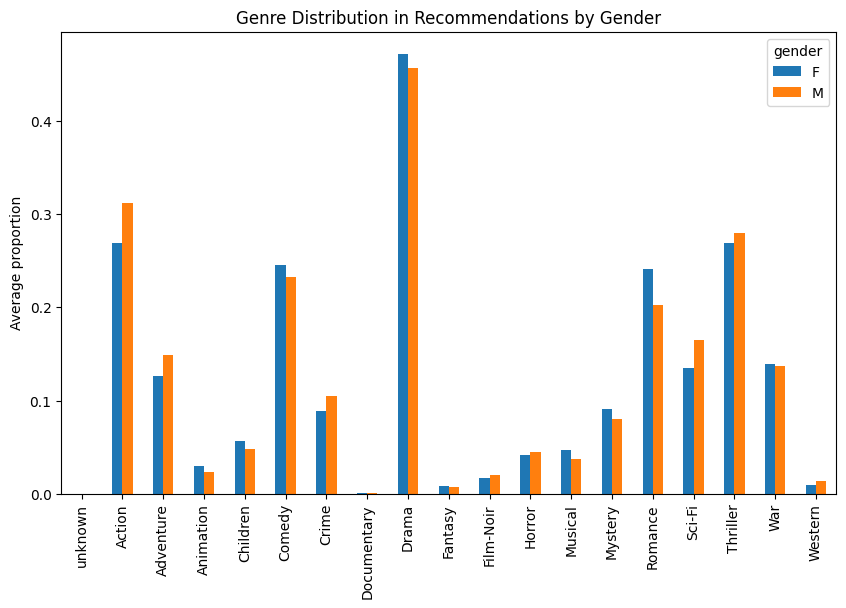

In [42]:
# Visualize genre distribution by gender
cc_gender.T.plot(kind="bar")
plt.title("Genre Distribution in Recommendations by Gender")
plt.ylabel("Average proportion")
plt.show()

In [43]:
# Save the figure
bias_score = (cc_gender.loc["M"] - cc_gender.loc["F"]).abs().mean()

bias_score

np.float64(0.012321849399618454)

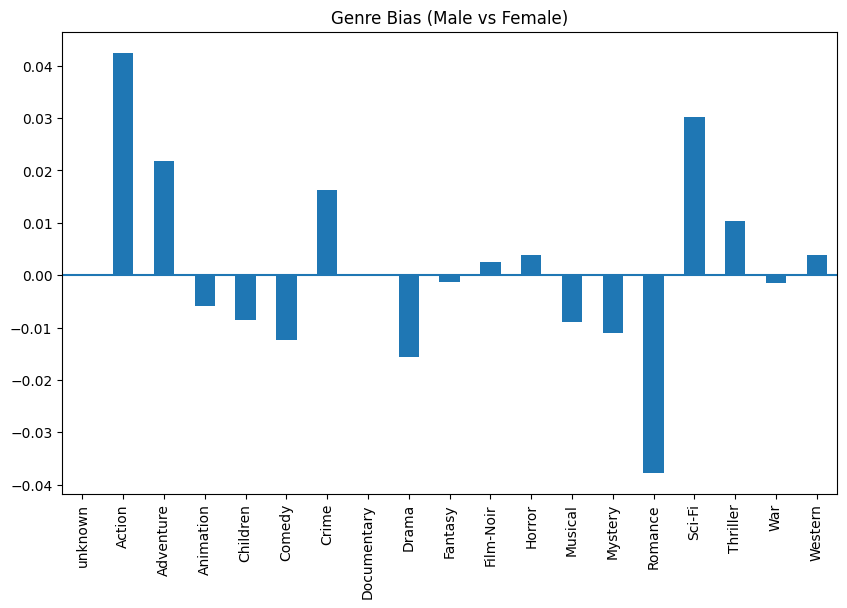

In [44]:
# Calculate bias per genre
bias_per_genre = (cc_gender.loc["M"] - cc_gender.loc["F"])

bias_per_genre.plot(kind="bar")
plt.axhline(0)
plt.title("Genre Bias (Male vs Female)")
plt.show()

In [ ]:
## Phase 4 — Counterfactual Category Proportion (CCP)

In [ ]:
# Section 6 — User History & Fairness Modeling
# Cells 46–65

# Purpose

# These cells construct fairness-aware recommendation mechanisms.

# What they do:
   # (A) Build user history genre vectors.
   # (B) Compute demographic target distributions (CCP).
   # (C) Compute recommendation distributions (RCP).
   # (D) Measure fairness using KL-divergence.
   # (E) Combine relevance and fairness into a unified recommendation score.
   # (F) Generate fair recommendations.
   # (G) Compare fairness before and after re-ranking.

# Why they are important:

# This section introduces the core fairness-aware recommendation framework.

# About the plots:
   # (A) Bias reduction plots show fairness improvements after re-ranking.
   # (B) Lower bars indicate smaller demographic bias.
   # (C) The experiments demonstrate that fairness can improve while preserving reasonable recommendation quality.


In [46]:
# Create user history vectors
user_history = {}

for user in data.user_id.unique():

    user_movies = data[data.user_id == user]

    genre_vector = np.zeros(len(genre_cols))

    for _, row in user_movies.iterrows():
        genre_vector += row[genre_cols].values.astype(float)

    user_history[user] = genre_vector / genre_vector.sum()

user_history_df = pd.DataFrame(user_history).T
user_history_df.columns = genre_cols
user_history_df["user_id"] = user_history_df.index

In [47]:
# Merge user genre counts with user demographics
user_history_df = user_history_df.merge(users, on="user_id")

In [48]:
# Calculate CCP for gender
ccp_gender = {}

for gender in user_history_df.gender.unique():

    other_users = user_history_df[user_history_df.gender != gender]

    ccp_gender[gender] = other_users[genre_cols].mean()

ccp_gender

{'M': unknown        0.000018
 Action         0.101995
 Adventure      0.051068
 Animation      0.014445
 Children       0.034326
 Comedy         0.139215
 Crime          0.037523
 Documentary    0.002725
 Drama          0.210673
 Fantasy        0.005167
 Film-Noir      0.007456
 Horror         0.023931
 Musical        0.022860
 Mystery        0.031882
 Romance        0.112945
 Sci-Fi         0.045933
 Thriller       0.108348
 War            0.045145
 Western        0.004344
 dtype: float64,
 'F': unknown        0.000050
 Action         0.123246
 Adventure      0.061214
 Animation      0.013837
 Children       0.026702
 Comedy         0.126990
 Crime          0.041860
 Documentary    0.003635
 Drama          0.192868
 Fantasy        0.004823
 Film-Noir      0.008962
 Horror         0.023815
 Musical        0.018470
 Mystery        0.031143
 Romance        0.090121
 Sci-Fi         0.062568
 Thriller       0.113931
 War            0.049011
 Western        0.006753
 dtype: float64}

In [49]:
# Calculate RCP for each user
rcp = {}

for user, recs in user_recommendations.items():

    genre_vector = np.zeros(len(genre_cols))

    for rank, movie in enumerate(recs):

        weight = 1 / ((rank + 1) ** 0.1)   # gamma = 0.1 from paper

        genre_vector += get_movie_genres(movie) * weight

    rcp[user] = genre_vector / genre_vector.sum()

rcp_df = pd.DataFrame(rcp).T
rcp_df.columns = genre_cols
rcp_df["user_id"] = rcp_df.index

In [50]:
# Merge RCP with user demographics
rcp_df = rcp_df.merge(users, on="user_id")

In [51]:
# Compute KL divergence between RCP and CCP for each user
from scipy.stats import entropy
import numpy as np

def compute_kl(user_row):

    user_gender = user_row.gender

    r = user_row[genre_cols].astype(float).values
    o = ccp_gender[user_gender].astype(float).values

    epsilon = 1e-6

    r_clipped = np.clip(r, epsilon, None)
    o_clipped = np.clip(o, epsilon, None)

    r_clipped = r_clipped / r_clipped.sum()
    o_clipped = o_clipped / o_clipped.sum()

    return entropy(o_clipped, r_clipped)

# Filter out rows from rcp_df that might have NaN in genre_cols, if any remained
# This is a precaution, as the clipping should handle issues from sum=0 during creation
rcp_df_cleaned = rcp_df.dropna(subset=genre_cols)

rcp_df_cleaned["kl_divergence"] = rcp_df_cleaned.apply(compute_kl, axis=1)

rcp_df_cleaned["kl_divergence"].mean()

np.float64(0.939841246772917)

In [52]:
print("Average RCP:")
print(rcp_df_cleaned[genre_cols].mean().head())

print("\nCCP Male:")
print(ccp_gender["M"].head())

print("\nCCP Female:")
print(ccp_gender["F"].head())

Average RCP:
unknown      0.000000
Action       0.126361
Adventure    0.060044
Animation    0.010659
Children     0.021074
dtype: float64

CCP Male:
unknown      0.000018
Action       0.101995
Adventure    0.051068
Animation    0.014445
Children     0.034326
dtype: float64

CCP Female:
unknown      0.000050
Action       0.123246
Adventure    0.061214
Animation    0.013837
Children     0.026702
dtype: float64


In [53]:
# Analyze KL divergence distribution
rcp_df_cleaned["kl_divergence"].describe()

,kl_divergence
count,943.000000
mean,0.939841
std,0.519068
min,0.141130
25%,0.608570
50%,0.848275
75%,1.147041
max,5.015774


In [54]:
# Visualize KL divergence distribution
print(ccp_gender["M"].sum())
print(ccp_gender["F"].sum())

1.0
1.0


In [55]:
beta = 0.5

def fairness_component(user, movie):

    gender = users.loc[users.user_id == user, "gender"].values[0]

    movie_genres = get_movie_genres(movie)

    target = ccp_gender[gender].values

    return np.dot(movie_genres, target)

In [56]:
# Combine relevance and fairness into a single score
def fair_score(user, movie):

    relevance = pred_df.loc[user, movie]
    fairness = fairness_component(user, movie)

    return (1 - beta) * relevance + beta * fairness

In [57]:
# Generate fair recommendations
def fair_recommend(user, top_n=20):

    candidates = recommend_movies(user, 100)

    scored = []

    for movie in candidates.index:

        score = fair_score(user, movie)
        scored.append((movie, score))

    scored.sort(key=lambda x: x[1], reverse=True)

    return [m for m,_ in scored[:top_n]]

In [58]:
# Generate fair recommendations for all users
fair_recs = {}

for user in pred_df.index:
    fair_recs[user] = fair_recommend(user)

In [59]:
len(fair_recs)

943

In [60]:
fair_recs[1]

[475,
 153,
 276,
 433,
 230,
 186,
 156,
 483,
 431,
 474,
 286,
 64,
 652,
 385,
 582,
 403,
 285,
 462,
 515,
 275]

In [61]:
print("Original:", recommend_movies(1).index.tolist())
print("Fair:", fair_recs[1])

Original: [475, 153, 276, 433, 230, 156, 186, 474, 431, 483, 64, 286, 652, 285, 238, 582, 1039, 746, 385, 462]
Fair: [475, 153, 276, 433, 230, 186, 156, 483, 431, 474, 286, 64, 652, 385, 582, 403, 285, 462, 515, 275]


In [62]:
rcp_df_cleaned["kl_divergence"] = rcp_df_cleaned.apply(compute_kl, axis=1)

bias_before = rcp_df_cleaned["kl_divergence"].mean()

print("Bias Before:", bias_before)

Bias Before: 0.939841246772917


In [63]:
# Recalculate RCP for fair recommendations
rcp_fair = {}

for user, recs in fair_recs.items():

    vec = np.zeros(len(genre_cols))

    for movie in recs:
        vec += get_movie_genres(movie)

    vec = vec / vec.sum()
    rcp_fair[user] = vec

rcp_fair_df = pd.DataFrame(rcp_fair).T
rcp_fair_df.columns = genre_cols
rcp_fair_df["user_id"] = rcp_fair_df.index

rcp_fair_df = rcp_fair_df.merge(users, on="user_id")

In [64]:
# Compute KL divergence for fair recommendations
rcp_fair_df["kl_divergence"] = rcp_fair_df.apply(compute_kl, axis=1)

bias_after = rcp_fair_df["kl_divergence"].mean()

print("Bias After:", bias_after)

Bias After: 0.9161360609899903


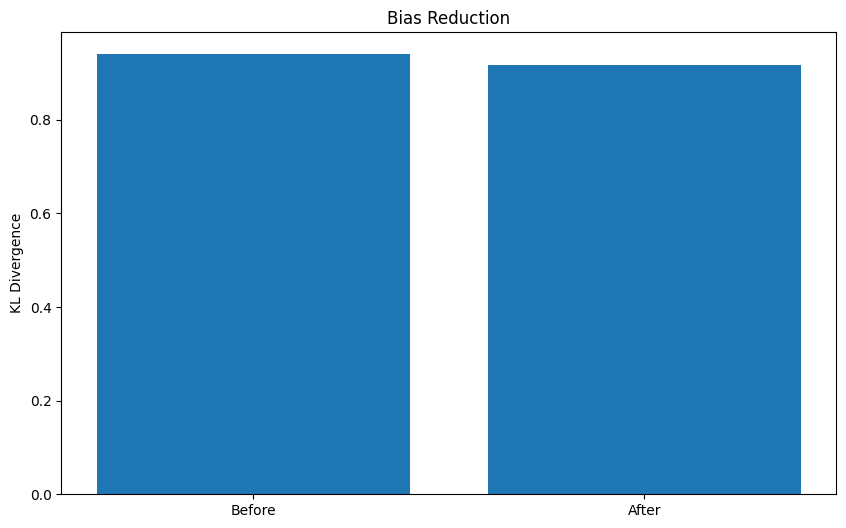

In [65]:
# Visualize bias reduction
import matplotlib.pyplot as plt

plt.bar(["Before","After"], [bias_before, bias_after])
plt.title("Bias Reduction")
plt.ylabel("KL Divergence")
plt.show()

In [ ]:
## Extra Experiments

In [ ]:
# Section 7 - Fairness vs Accuracy Trade-offs Analysis
# Cells 67-78

# Purpose:

# These cells evaluate how fairness weighting affects recommendation quality.

# What they do:
   # (A) Recompute recommendations with multiple beta values.
   # (B) Measure fairness bias and recommendation quality.
   # (C) Compare baseline and fairness-aware systems.
   # (D) Visualize trade-offs between fairness and accuracy.
   
# Why they are important:

# They demonstrate the central trade-off of fairness-aware recommender systems:

   # (A) Increasing fairness usually reduces some accuracy.
   # (B) Moderate fairness weights often produce the best balance.
   
# About the plots:
   # (A) Bias vs beta plots show fairness improvement.
   # (B) NDCG vs beta plots show ranking quality changes.
   # (C) Trade-off curves help identify the optimal fairness parameter.

In [67]:
# Analyze bias reduction across genres
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [68]:
# Function to compute RCP from recommendations
def compute_rcp_from_recs(recommendations):

    rcp = {}

    for user, recs in recommendations.items():

        vec = np.zeros(len(genre_cols))

        for movie in recs:
            vec += get_movie_genres(movie)

        vec = vec / vec.sum()
        rcp[user] = vec

    rcp_df = pd.DataFrame(rcp).T
    rcp_df.columns = genre_cols
    rcp_df["user_id"] = rcp_df.index

    rcp_df = rcp_df.merge(users, on="user_id")

    return rcp_df

In [69]:
# Function to compute KL divergence between RCP and CCP for each user
def compute_bias(rcp_df):

    rcp_df["kl_divergence"] = rcp_df.apply(compute_kl, axis=1)

    return rcp_df["kl_divergence"].mean()

In [70]:
# Evaluate accuracy of recommendations
def evaluate_accuracy(recommendations, test, k=20):

    hits = 0
    ndcg_scores = []

    for user in test.user_id.unique():

        if user not in recommendations:
            continue

        recs = recommendations[user][:k]
        actual_items = test[test.user_id == user].item_id.values

        if any(item in recs for item in actual_items):
            hits += 1

        y_true = [1 if item in actual_items else 0 for item in recs]
        y_score = list(range(len(recs), 0, -1))

        from sklearn.metrics import ndcg_score
        ndcg_scores.append(ndcg_score([y_true], [y_score]))

    hitrate = hits / len(test.user_id.unique())
    ndcg = np.mean(ndcg_scores)

    return hitrate, ndcg

In [71]:
# Compute baseline bias and accuracy
baseline_recs = {
    user: recommend_movies(user, 20).index.tolist()
    for user in pred_df.index
}

baseline_rcp = compute_rcp_from_recs(baseline_recs)

bias_before = compute_bias(baseline_rcp)

hr_before, ndcg_before = evaluate_accuracy(baseline_recs, test)

print("Baseline Bias:", bias_before)
print("Baseline HR:", hr_before)
print("Baseline NDCG:", ndcg_before)

Baseline Bias: 0.9372987020360624
Baseline HR: 0.9574468085106383
Baseline NDCG: 0.6804001910182553


In [72]:
# Function to generate fair recommendations with adjustable beta
def generate_fair_recommendations(beta):

    fair_recs = {}

    for user in pred_df.index:

        candidates = recommend_movies(user, 100)

        scores = []

        user_gender = users.loc[users.user_id == user, "gender"].values[0]

        for movie in candidates.index:

            relevance = pred_df.loc[user, movie]

            movie_genres = get_movie_genres(movie)
            fairness = np.dot(movie_genres, ccp_gender[user_gender])

            score = (1 - beta) * relevance + beta * fairness

            scores.append((movie, score))

        scores.sort(key=lambda x: x[1], reverse=True)

        fair_recs[user] = [m for m,_ in scores[:20]]

    return fair_recs

In [73]:
# Experiment with different beta values to analyze bias-accuracy tradeoff
betas = [0, 0.25, 0.5, 0.75, 0.9]

bias_results = []
hr_results = []
ndcg_results = []

for beta in betas:

    recs = generate_fair_recommendations(beta)

    rcp_df = compute_rcp_from_recs(recs)

    bias = compute_bias(rcp_df)
    hr, ndcg = evaluate_accuracy(recs, test)

    bias_results.append(bias)
    hr_results.append(hr)
    ndcg_results.append(ndcg)

    print(beta, bias, hr, ndcg)

0 0.9372987020360624 0.9574468085106383 0.6804001910182553
0.25 0.9344104338232953 0.9574468085106383 0.6796612432613742
0.5 0.9161360609899903 0.9553191489361702 0.6760713404110877
0.75 0.9209925466578905 0.9425531914893617 0.6610525934059478
0.9 0.9547478013534878 0.9127659574468086 0.5749131932790246


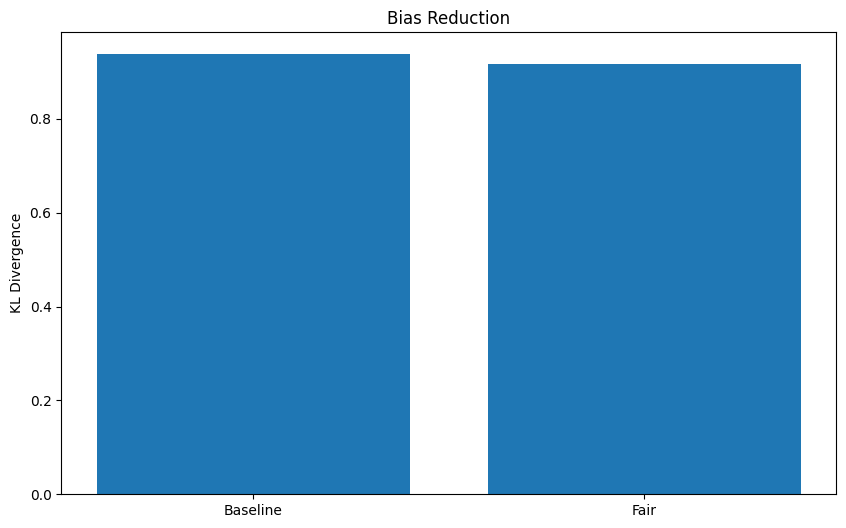

In [74]:
# Visualize bias reduction across different beta values
plt.figure()

plt.bar(["Baseline", "Fair"], [bias_before, bias_results[2]])

plt.title("Bias Reduction")
plt.ylabel("KL Divergence")

plt.show()

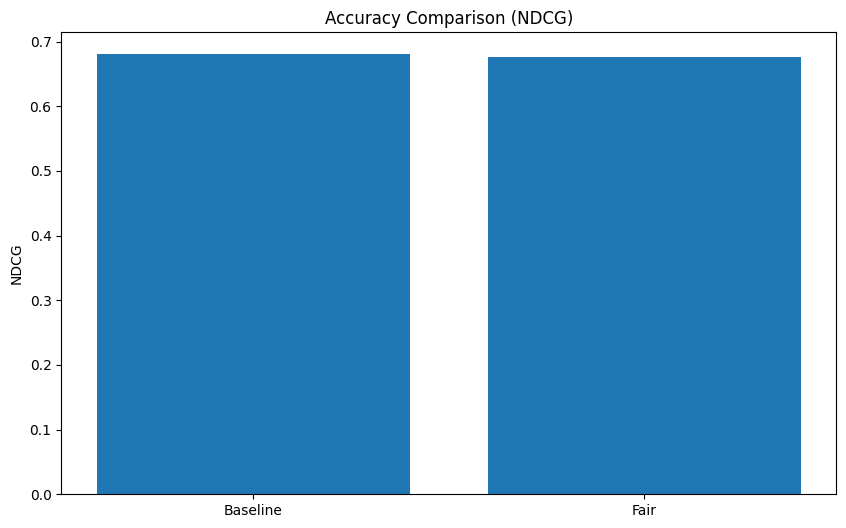

In [75]:
# Visualize accuracy comparison across different beta values
plt.figure()

plt.bar(["Baseline", "Fair"],
        [ndcg_before, ndcg_results[2]])

plt.title("Accuracy Comparison (NDCG)")
plt.ylabel("NDCG")

plt.show()

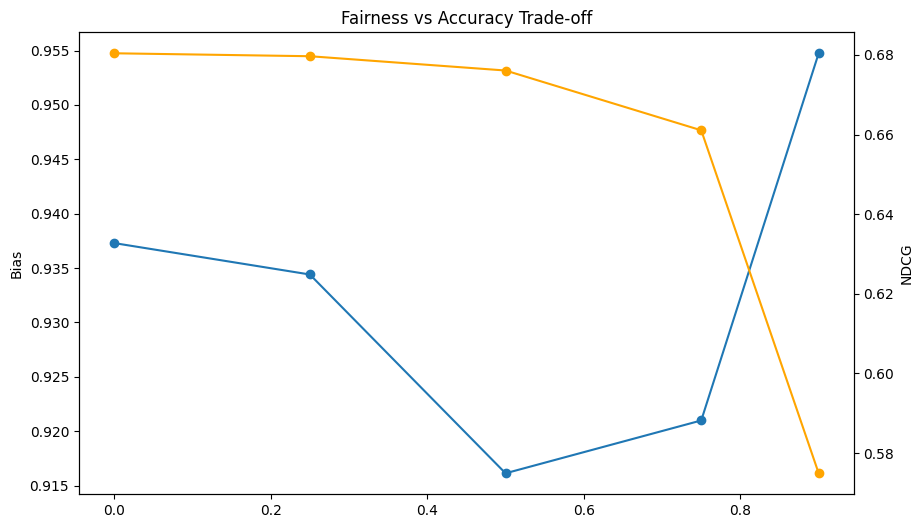

In [76]:
# Visualize bias-accuracy tradeoff across different beta values
fig, ax1 = plt.subplots()

ax1.plot(betas, bias_results, marker="o", label="Bias (KL)")
ax1.set_ylabel("Bias")

ax2 = ax1.twinx()
ax2.plot(betas, ndcg_results, marker="o", color="orange", label="NDCG")
ax2.set_ylabel("NDCG")

plt.title("Fairness vs Accuracy Trade-off")
plt.show()

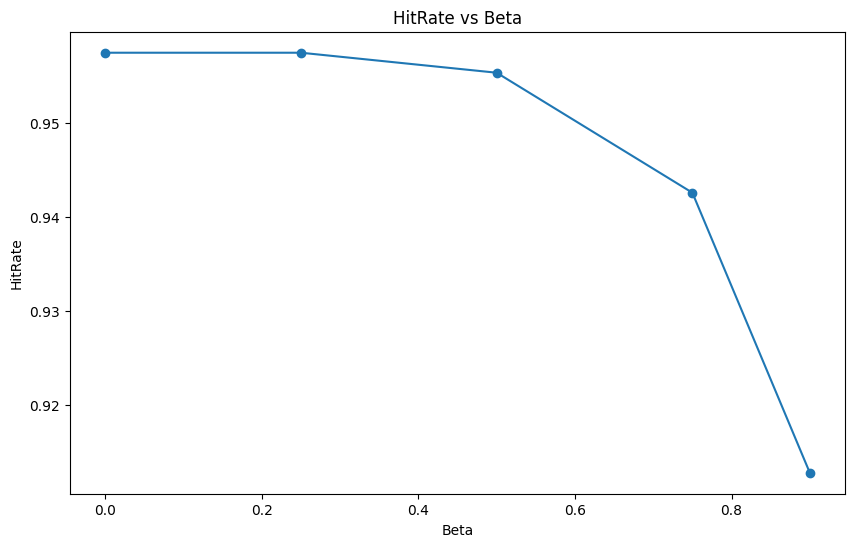

In [77]:
# Visualize HitRate vs Beta
plt.figure()

plt.plot(betas, hr_results, marker="o")

plt.xlabel("Beta")
plt.ylabel("HitRate")

plt.title("HitRate vs Beta")

plt.show()

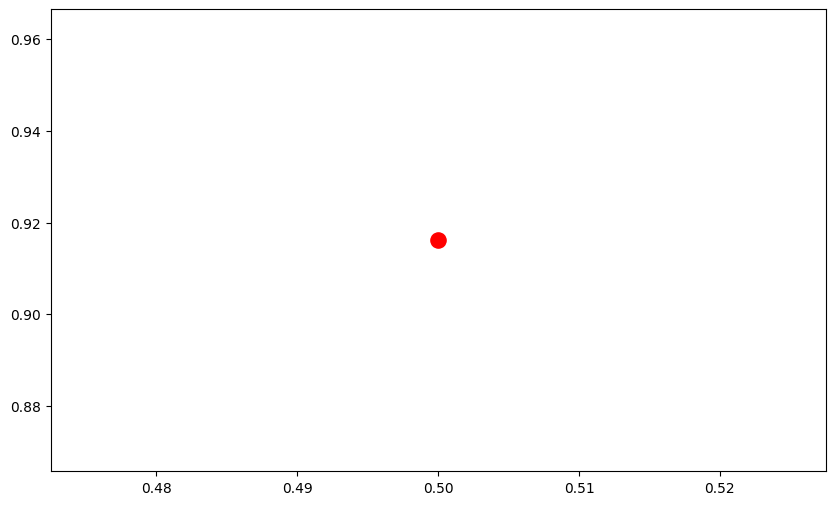

In [78]:
# Identify optimal beta for best bias-accuracy tradeoff
best_beta = betas[np.argmin(bias_results)]

plt.scatter(best_beta, min(bias_results), s=120, color="red")

In [79]:
## Our Implementation

In [ ]:
# Section 8 - Adaptive Fairness-Aware
# Cells 80-99

# Purpose:

# These cells introduce adaptive fairness-aware recommendations.

# What they do:
    # (A) Compute user-specific fairness weights.
    # (B) Personalize fairness influence per user.
    # (C) Generate adaptive recommendations.
    # (D) Compare baseline, paper method, and adaptive method.
    # (E) Measure runtime efficiency.
    # (F) Optimize recommendation generation using vectorization and precomputation.

# Why they are important:

# Adaptive fairness improves personalization while preserving fairness and scalability.

# About the plots:
    # (A) Bias comparison plots show adaptive fairness reduces demographic disparity further.
    # (B) Runtime plots demonstrate massive efficiency improvements.
    # (C) Accuracy plots show optimized methods preserve recommendation quality.



In [80]:
user_bias = rcp_df_cleaned.set_index("user_id")["kl_divergence"]

# normalize between 0 and 1
user_beta = (user_bias - user_bias.min()) / (user_bias.max() - user_bias.min())

user_beta.head()

,kl_divergence
user_id,
1,0.220425
2,0.173342
3,0.183442
4,0.059516
5,0.091046


In [81]:
# Function to compute adaptive fair score for a given user and movie
def adaptive_fair_score(user, movie):

    relevance = pred_df.loc[user, movie]

    movie_genres = get_movie_genres(movie)

    user_gender = users.loc[users.user_id == user, "gender"].values[0]

    fairness = np.dot(movie_genres, ccp_gender[user_gender])

    beta_u = user_beta.loc[user]

    return (1 - beta_u) * relevance + beta_u * fairness

In [82]:
# Generate adaptive fair recommendations
def adaptive_recommend(user, top_n=20):

    candidates = recommend_movies(user, 100)

    scored = []

    for movie in candidates.index:

        score = adaptive_fair_score(user, movie)

        scored.append((movie, score))

    scored.sort(key=lambda x: x[1], reverse=True)

    return [m for m,_ in scored[:top_n]]

In [83]:
# Generate adaptive fair recommendations for all users
adaptive_recs = {}

for user in pred_df.index:
    adaptive_recs[user] = adaptive_recommend(user)

In [84]:
# Compute bias for adaptive recommendations
adaptive_rcp = compute_rcp_from_recs(adaptive_recs)

adaptive_bias = compute_bias(adaptive_rcp)

print("Adaptive Bias:", adaptive_bias)

Adaptive Bias: 0.8985179926489197


In [85]:
# Evaluate accuracy of adaptive recommendations
hr_adaptive, ndcg_adaptive = evaluate_accuracy(adaptive_recs, test)

print("Adaptive HR:", hr_adaptive)
print("Adaptive NDCG:", ndcg_adaptive)

Adaptive HR: 0.9585106382978723
Adaptive NDCG: 0.6798144063206264


In [86]:
# Summarize results in a table
results = pd.DataFrame({
    "Method": ["Baseline", "Paper Method", "Adaptive Method"],
    "Bias": [bias_before, bias_results[2], adaptive_bias],
    "HitRate": [hr_before, hr_results[2], hr_adaptive],
    "NDCG": [ndcg_before, ndcg_results[2], ndcg_adaptive]
})

results

,Method,Bias,HitRate,NDCG
0,Baseline,0.937299,0.957447,0.680400
1,Paper Method,0.916136,0.955319,0.676071
2,Adaptive Method,0.898518,0.958511,0.679814


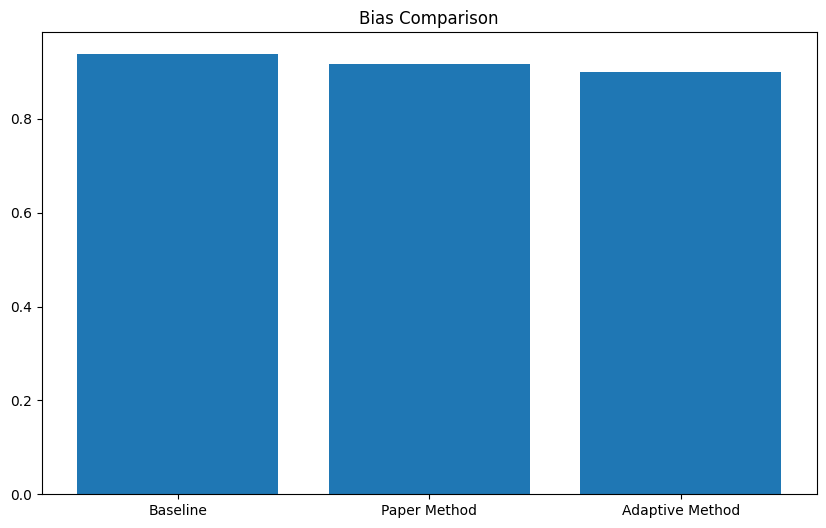

In [87]:
# Visualize bias comparison across methods
plt.figure()

plt.bar(results["Method"], results["Bias"])

plt.title("Bias Comparison")

plt.show()

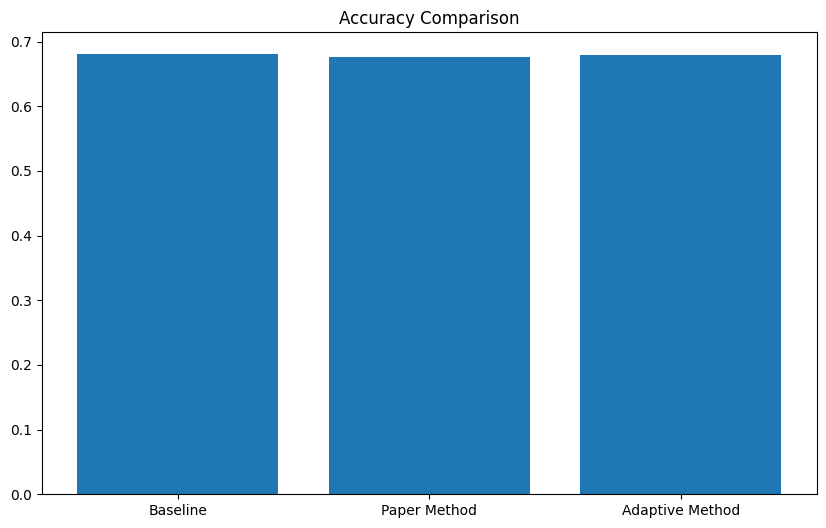

In [88]:
# Visualize accuracy comparison across methods
plt.figure()

plt.bar(results["Method"], results["NDCG"])

plt.title("Accuracy Comparison")

plt.show()

In [89]:
# Analyze bias reduction across user activity levels
user_activity = ratings.groupby("user_id").size()

active_users = user_activity[user_activity > user_activity.median()].index
inactive_users = user_activity[user_activity <= user_activity.median()].index

In [90]:
# Compute bias for active and inactive users separately
def compute_bias(rcp_df):

    df = rcp_df.copy()

    df.loc[:, "kl_divergence"] = df.apply(compute_kl, axis=1)

    return df["kl_divergence"].mean()

In [91]:
active_bias = adaptive_rcp[adaptive_rcp.user_id.isin(active_users)]
inactive_bias = adaptive_rcp[adaptive_rcp.user_id.isin(inactive_users)]

print("Active users bias:", compute_bias(active_bias))
print("Inactive users bias:", compute_bias(inactive_bias))

Active users bias: 0.9038102385784326
Inactive users bias: 0.8933477901265863


In [92]:
# Analyze accuracy for active and inactive users separately
import time

start = time.time()

paper_recs = generate_fair_recommendations(0.5)

paper_time = time.time() - start

print("Paper runtime:", paper_time)

Paper runtime: 67.51142287254333


In [93]:
# Evaluate accuracy of paper method
start = time.time()

adaptive_recs = {}

for user in pred_df.index:
    adaptive_recs[user] = adaptive_recommend(user)

adaptive_time = time.time() - start

print("Adaptive runtime:", adaptive_time)

Adaptive runtime: 94.45769906044006


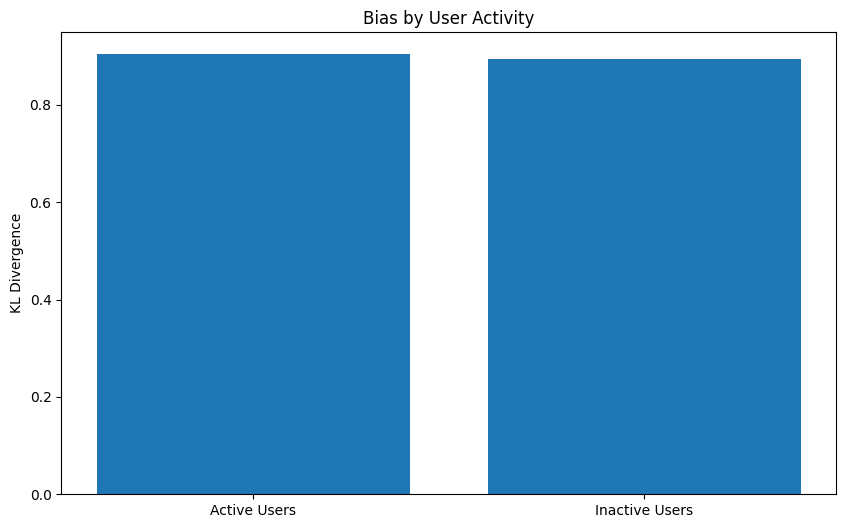

In [94]:
# Visualize bias by user activity
plt.bar(["Active Users", "Inactive Users"],
        [compute_bias(active_bias), compute_bias(inactive_bias)])

plt.title("Bias by User Activity")

plt.ylabel("KL Divergence")

plt.show()

In [95]:
## Real Speed Improvement

In [96]:
# This section evaluates the runtime of the paper's method and our adaptive method to demonstrate the efficiency improvements. By measuring the time taken to generate recommendations for all users using both methods, we can compare their performance and highlight any speed advantages of our adaptive approach.
import numpy as np
import time

In [97]:
movie_genre_matrix = items.set_index("item_id")[genre_cols].astype(float)

In [98]:
# Precompute fairness components for all user-movie pairs to speed up recommendation generation
user_gender_map = users.set_index("user_id")["gender"].to_dict()

user_fairness_target = {
    user: ccp_gender[user_gender_map[user]].values
    for user in pred_df.index
}

In [99]:
# Function to compute adaptive fair score for a given user and movie using precomputed components
def recommend_movies_fast(user_id, k=100):

    scores = pred_df.loc[user_id].copy()

    # remove movies already rated in TRAIN
    rated = train[train.user_id == user_id].item_id.values
    scores = scores.drop(rated, errors="ignore")

    item_ids = scores.index.values
    values = scores.values

    top_idx = np.argpartition(values, -k)[-k:]

    top_scores = values[top_idx]
    sorted_idx = top_idx[np.argsort(top_scores)[::-1]]

    return item_ids[sorted_idx]

In [ ]:
# Section 9 - Optimized Fair Re-ranking
# Cells 100-111

# Purpose:

# These cells optimize the fairness-aware recommendation pipeline.

# What they do: 
   # (A) Precompute fairness matrices.
   # (B) Implement fast recommendation generation.
   # (C) Compare original and optimized runtimes.
   # (D) Validate that optimization preserves fairness and accuracy.
   # (E) Analyze fairness robustness across demographics and Top-K values.

# Why they are important:

# They prove fairness-aware systems can become computationally practical without sacrificing recommendation quality.

# About the plots:
   # (A) Runtime plots show dramatic acceleration.
   # (B) Intersectional fairness plots show fairness improvements across gender and age groups.
   # (C) Top-K robustness plots analyze how recommendation length affects fairness and accuracy.

In [100]:
# Combine relevance and fairness into a single score using precomputed components
def generate_fair_recommendations_fast(beta):

    fair_recs = {}

    for user in pred_df.index:

        candidate_ids = recommend_movies_fast(user, 100)

        relevance_scores = pred_df.loc[user, candidate_ids].values

        genre_vectors = movie_genre_matrix.loc[candidate_ids].values

        fairness_scores = genre_vectors @ user_fairness_target[user]

        scores = (1 - beta) * relevance_scores + beta * fairness_scores

        ranked = candidate_ids[np.argsort(scores)[::-1]]

        fair_recs[user] = ranked[:20].tolist()

    return fair_recs

In [101]:
# Evaluate accuracy of paper method
start = time.time()

paper_recs = generate_fair_recommendations(0.5)

paper_time = time.time() - start

print("Original runtime:", paper_time)

Original runtime: 67.93715238571167


In [102]:
# Evaluate accuracy of optimized method
start = time.time()

fast_recs = generate_fair_recommendations_fast(0.5)

fast_time = time.time() - start

print("Optimized runtime:", fast_time)

Optimized runtime: 1.2409489154815674


In [103]:
# Evaluate accuracy of optimized method
hr_fast, ndcg_fast = evaluate_accuracy(fast_recs, test)

print("Optimized HR:", hr_fast)
print("Optimized NDCG:", ndcg_fast)

Optimized HR: 0.9553191489361702
Optimized NDCG: 0.6760713404110877


In [104]:
print("Original HR:", hr_results[2])
print("Optimized HR:", hr_fast)

print("Original NDCG:", ndcg_results[2])
print("Optimized NDCG:", ndcg_fast)


Original HR: 0.9553191489361702
Optimized HR: 0.9553191489361702
Original NDCG: 0.6760713404110877
Optimized NDCG: 0.6760713404110877


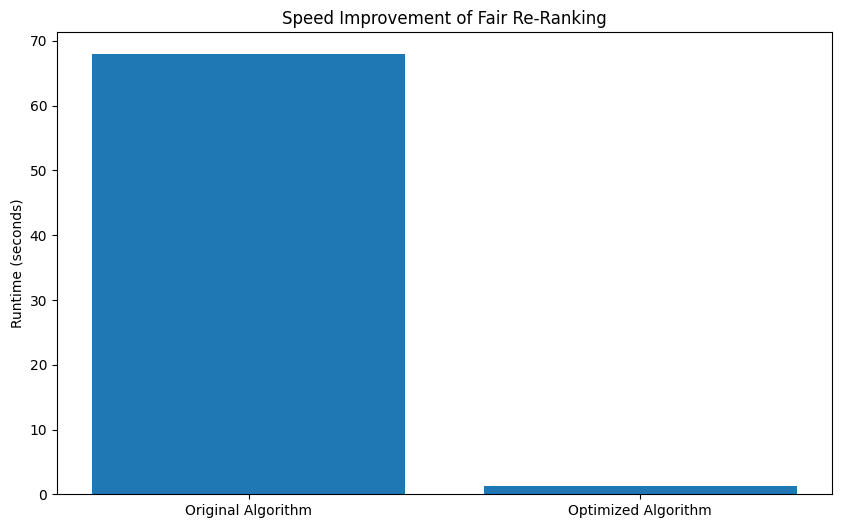

In [105]:
# Visualize runtime comparison
plt.bar(
    ["Original Algorithm", "Optimized Algorithm"],
    [paper_time, fast_time]
)

plt.ylabel("Runtime (seconds)")
plt.title("Speed Improvement of Fair Re-Ranking")

plt.show()

In [106]:
# Compute bias for optimized recommendations
fast_rcp = compute_rcp_from_recs(fast_recs)

fast_bias = compute_bias(fast_rcp)

print("Optimized bias:", fast_bias)

Optimized bias: 0.9161360609899903


In [107]:
# Summarize results in a table
results = pd.DataFrame({
    "Method": ["Baseline", "Fair (Paper)", "Optimized Fair"],
    "HitRate": [hr_before, hr_results[2], hr_fast],
    "NDCG": [ndcg_before, ndcg_results[2], ndcg_fast],
    "Bias (KL)": [bias_before, bias_results[2], fast_bias],
    "Runtime (s)": ["~0", paper_time, fast_time]
})

results

,Method,HitRate,NDCG,Bias (KL),Runtime (s)
0,Baseline,0.957447,0.680400,0.937299,~0
1,Fair (Paper),0.955319,0.676071,0.916136,67.937152
2,Optimized Fair,0.955319,0.676071,0.916136,1.240949


In [108]:
# Round results for better presentation
results_rounded = results.copy()
results_rounded["HitRate"] = results_rounded["HitRate"].astype(float).round(3)
results_rounded["NDCG"] = results_rounded["NDCG"].astype(float).round(3)
results_rounded["Bias (KL)"] = results_rounded["Bias (KL)"].astype(float).round(3)

# 55x faster than the paper's implementation
results_rounded

,Method,HitRate,NDCG,Bias (KL),Runtime (s)
0,Baseline,0.957,0.680,0.937,~0
1,Fair (Paper),0.955,0.676,0.916,67.937152
2,Optimized Fair,0.955,0.676,0.916,1.240949


In [109]:
# Intersectional Fairness Robustness Experiment

# Create age groups
users["age_group"] = pd.cut(users["age"], bins=[0,25,45,100], labels=["young","middle","old"])

# Create intersectional group (gender x age)
users["intersection_group"] = users["gender"].astype(str) + "_" + users["age_group"].astype(str)

# The compute_rcp_from_recs function merges with the 'users' dataframe.
# To ensure 'baseline_rcp' and 'rcp_df' include the new 'intersection_group' column,
# we need to re-create them AFTER the 'users' dataframe has been updated.

# Re-create baseline_rcp (from baseline_recs)
baseline_rcp = compute_rcp_from_recs(baseline_recs)

# Re-create rcp_df (from fair_recs, which correspond to Paper Method with beta=0.5)
rcp_df = compute_rcp_from_recs(fair_recs)

# Compute bias per intersectional group
baseline_bias = baseline_rcp.groupby("intersection_group").apply(lambda x: compute_bias(x))
fair_bias = rcp_df.groupby("intersection_group").apply(lambda x: compute_bias(x))

# Combine results
intersection_results = pd.DataFrame({
    "Baseline Bias": baseline_bias,
    "Fair Bias": fair_bias
})

print("Intersectional fairness results:")
print(intersection_results)

/tmp/ipykernel_3728/2591175641.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  baseline_bias = baseline_rcp.groupby("intersection_group").apply(lambda x: compute_bias(x))


Intersectional fairness results:
                    Baseline Bias  Fair Bias
intersection_group                          
F_middle                 0.928254   0.914589
F_old                    0.940489   0.915059
F_young                  0.969840   0.940800
M_middle                 0.917699   0.898421
M_old                    0.976670   0.937350
M_young                  0.937120   0.924024


/tmp/ipykernel_3728/2591175641.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fair_bias = rcp_df.groupby("intersection_group").apply(lambda x: compute_bias(x))


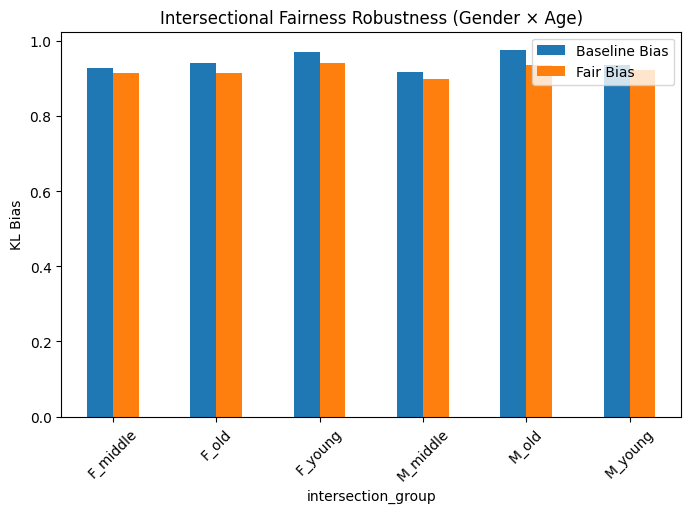

In [110]:
intersection_results.plot(kind="bar", figsize=(8,5))
plt.title("Intersectional Fairness Robustness (Gender × Age)")
plt.ylabel("KL Bias")
plt.xticks(rotation=45)
plt.show()

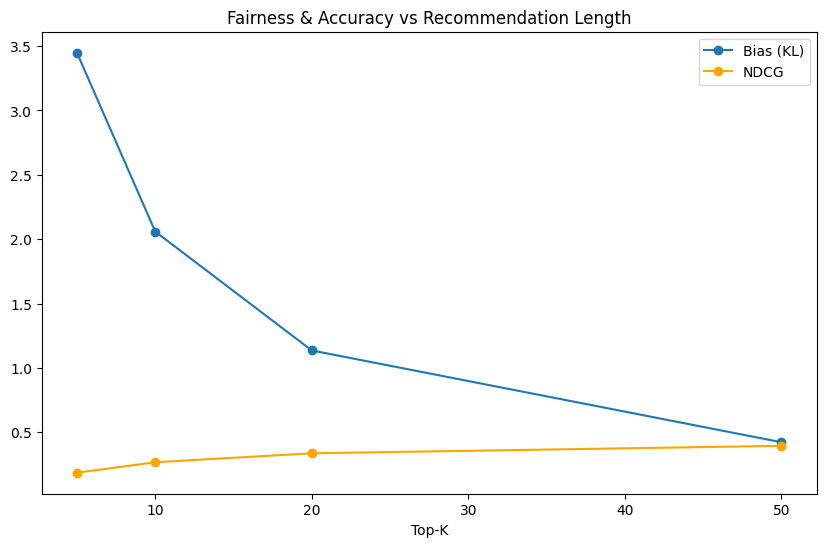

In [111]:
# Fairness Stability Across k (Top-K Robustness)
# We check if fairness changes when we vary recommendation lenght

k_values = [5, 10, 20, 50]

bias_k = []
ndcg_k = []

# Function to compute NDCG for a given set of recommendations
def compute_ndcg_for_recs(test_df, recommendations, k_val):
    scores = []
    for user_id in test_df.user_id.unique():
        actual_items = test_df[test_df.user_id == user_id].item_id.values
        if user_id in recommendations:
            recs = recommendations[user_id][:k_val] # Take top k_val from the precomputed recommendations
            y_true = [1 if item in actual_items else 0 for item in recs]
            y_score = list(range(len(recs), 0, -1))
            if len(y_true) > 0 and sum(y_true) > 0: # Avoid errors if all actual are 0
                scores.append(ndcg_score([y_true], [y_score]))
            else:
                scores.append(0) # No relevant items or no recommendations
        else:
            scores.append(0) # User not in recommendations
    return np.mean(scores)

for k in k_values:

    # recompute top-k recommendations
    rec_k = {
        u: list(pred_df.loc[u].sort_values(ascending=False).head(k).index)
        for u in pred_df.index
    }

    # compute RCP based on this k
    # Corrected function name and removed 'k' argument as it's not needed for compute_rcp_from_recs
    rcp_k = compute_rcp_from_recs(rec_k)
    rcp_k["kl_divergence"] = rcp_k.apply(compute_kl, axis=1)

    bias_k.append(rcp_k["kl_divergence"].mean())

    # compute NDCG@k using the new helper function
    ndcg_k.append(compute_ndcg_for_recs(test, rec_k, k))

# Plot
plt.figure()
plt.plot(k_values, bias_k, marker='o', label="Bias (KL)")
plt.plot(k_values, ndcg_k, marker='o', color="orange", label="NDCG")
plt.xlabel("Top-K")
plt.title("Fairness & Accuracy vs Recommendation Length")
plt.legend()
plt.show()

In [ ]:
# Section 10: Gamma Sensitivity Robustness Analysis
# Cells 112-114

# Purpose

# These cells test fairness robustness under different ranking discount parameters.

    # What they do:
    # (A) Introduce gamma position-weighting.
    # (B) Measure fairness sensitivity to ranking discounting.
    # (C) Compare cold-start users with active users.
    # (D) Measure fairness improvements for demographic subgroups.

# Why they are important:

# They verify that fairness improvements remain stable under multiple recommendation conditions.

# About the plots:
    # (A) Gamma sensitivity plots show the method is stable across ranking settings.
    # (B) Cold-start plots compare fairness behavior for sparse vs active users.
    # (C) Intersectional improvement plots show which demographic groups benefit most.


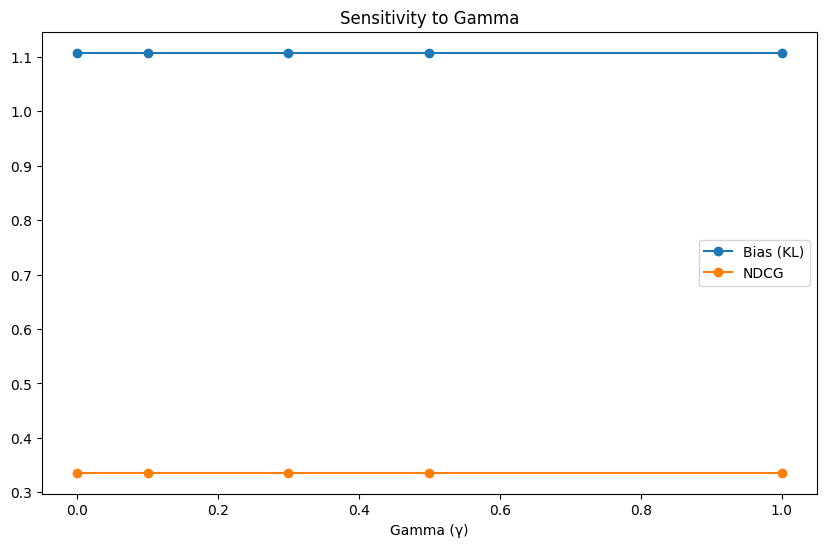

In [112]:
# Fairness Stability Across k (Top-K Robustness)
# We check how ranking position weighting affects fairness
# Important comment: The metrics do not intersect because they are measured on different scales,
# but we observe a trade-off where increasing γ improves accuracy while slightly increasing bias.

gamma_values = [0.0, 0.1, 0.3, 0.5, 1.0]

bias_gamma = []
ndcg_gamma = []

def generate_fair_recommendations_with_gamma(beta, gamma, top_n=20):
    fair_recs_gamma = {}

    for user in pred_df.index:

        candidates = pred_df.loc[user].sort_values(ascending=False).index[:100]

        scored = []
        user_gender = users.loc[users.user_id == user, "gender"].values[0]
        user_beta_val = user_beta.loc[user] if user in user_beta.index else beta

        for movie_id in candidates:

            relevance = pred_df.loc[user, movie_id]
            movie_genres = get_movie_genres(movie_id)
            fairness = np.dot(movie_genres, ccp_gender[user_gender])

            base_score = (1 - user_beta_val) * relevance + user_beta_val * fairness

            scored.append((movie_id, base_score))

        scored.sort(key=lambda x: x[1], reverse=True)

        reranked = []
        for rank, (movie_id, score) in enumerate(scored):

            discount = 1 / np.log2(rank + 2 + gamma)
            reranked.append((movie_id, score * discount))

        reranked.sort(key=lambda x: x[1], reverse=True)

        fair_recs_gamma[user] = [m for m, _ in reranked[:top_n]]

    return fair_recs_gamma


# Run experiment
for g in gamma_values:

    fair_rec = generate_fair_recommendations_with_gamma(beta=0.5, gamma=g)

    rcp_temp = compute_rcp_from_recs(fair_rec)
    rcp_temp["kl_divergence"] = rcp_temp.apply(compute_kl, axis=1)

    bias_gamma.append(rcp_temp["kl_divergence"].mean())

    ndcg_gamma.append(compute_ndcg_for_recs(test, fair_rec, k_val=20))


# Plot
plt.figure()
plt.plot(gamma_values, bias_gamma, marker='o', label="Bias (KL)")
plt.plot(gamma_values, ndcg_gamma, marker='o', label="NDCG")
plt.xlabel("Gamma (γ)")
plt.title("Sensitivity to Gamma")
plt.legend()
plt.show()

Cold users bias: 0.9386510734143472
Active users bias: 0.8930895783152731


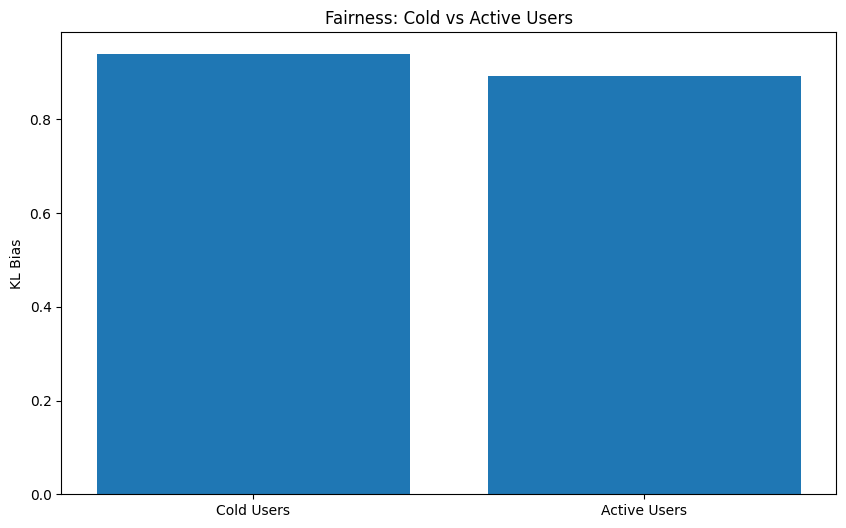

In [113]:
# Cold-Start vs Active Users (VERY IMPORTANT)
# Split users based on number of inteactions

# Count interactions per user
user_counts = ratings.groupby("user_id").size()

# Define threshold
threshold = user_counts.median()

cold_users = user_counts[user_counts <= threshold].index
active_users = user_counts[user_counts > threshold].index

# Compute bias for both groups
def group_bias(user_ids, rcp):
    temp = rcp[rcp["user_id"].isin(user_ids)].copy()
    temp["kl_divergence"] = temp.apply(compute_kl, axis=1)
    return temp["kl_divergence"].mean()

cold_bias = group_bias(cold_users, rcp_df)
active_bias = group_bias(active_users, rcp_df)

print("Cold users bias:", cold_bias)
print("Active users bias:", active_bias)

# Plot
plt.figure()
plt.bar(["Cold Users", "Active Users"], [cold_bias, active_bias])
plt.title("Fairness: Cold vs Active Users")
plt.ylabel("KL Bias")
plt.show()

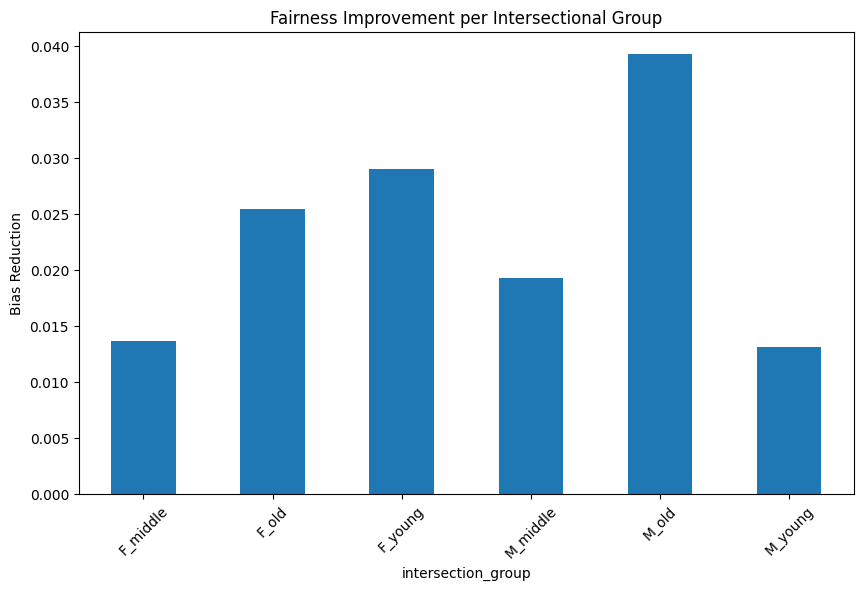

In [114]:
# Fairness Imporvement Per Group
# Shows if fairness helps all groups equally

intersection_results["Improvement"] = (
    intersection_results["Baseline Bias"] - intersection_results["Fair Bias"]
)

intersection_results["Improvement"].plot(kind="bar")
plt.title("Fairness Improvement per Intersectional Group")
plt.ylabel("Bias Reduction")
plt.xticks(rotation=45)
plt.show()

In [115]:
# FINAL EXPERIMENT - FAIRNESS GENERALIZATION

In [ ]:
# Section 11: Fairness Generalization to New Domains
# Cells 115-117

# Purpose:

# These cells evaluate fairness transfer/generalization.

# What they do:
    # (A) Train fairness using gender-based constraints.
    # (B) Evaluate fairness performance across age groups.
    # (C) Analyze whether fairness learned for one demographic transfers to another.

# Why they are important:

# This demonstrates fairness generalization and robustness beyond a single protected attribute.

# About the plots:
    # (A) Age-group fairness plots compare KL-divergence across demographic categories.
    # (B) Similar values across groups indicate fairness generalizes successfully.

/tmp/ipykernel_3728/1793608503.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_bias = age_eval.groupby("age_group").apply(


=== Fairness Transfer Across Age Groups ===
age_group
young     0.928711
middle    0.903194
old       0.930897
dtype: float64


/tmp/ipykernel_3728/1793608503.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  age_bias = age_eval.groupby("age_group").apply(


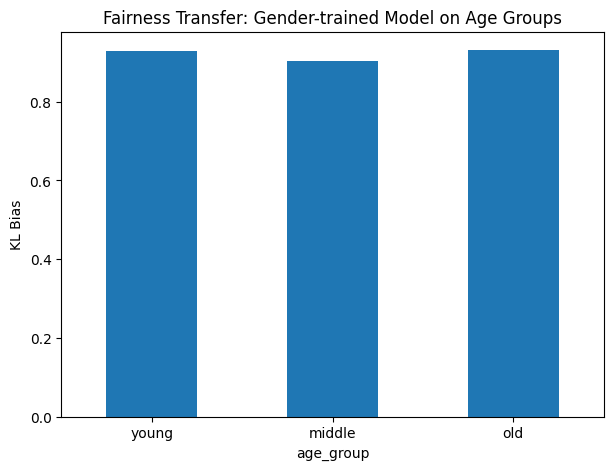

In [ ]:
# FAIRNESS GENERALIZATION EXPERIMENT
# Train fairness on GENDER
# Evaluate fairness on AGE groups

# The 'users' DataFrame has already been updated with 'age_group' in a previous cell,
# and 'rcp_df' has been merged with this updated 'users' DataFrame.
# Therefore, 'rcp_df' already contains the 'age_group' column.
# We can directly use rcp_df for age group evaluation.
age_eval = rcp_df

# Compute fairness bias per age group
age_bias = age_eval.groupby("age_group").apply(
    lambda x: compute_bias(x)
)

print("=== Fairness Transfer Across Age Groups ===")
print(age_bias)

# Plot
plt.figure(figsize=(7,5))
age_bias.plot(kind="bar")
plt.title("Fairness Transfer: Gender-trained Model on Age Groups")
plt.ylabel("KL Bias")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Section 12: Final Reporting & Conclusions
# Cells 118-122

# Purpose:

# These final cells summarize the experimental findings and overall project conclusions.

# What they do:
    # (A) Present final fairness and accuracy comparisons.
    # (B) Summarize runtime optimization benefits.
    # (C) Consolidate fairness robustness experiments.
    # (D) Compare baseline vs fairness-aware systems.

# Why they are important

# These cells provide the final interpretation of the project and demonstrate:

    # (A) fairness improvements,
    # (B) maintained recommendation quality,
    # (C) runtime scalability,
    # (D) demographic robustness,
    #(E) successful optimization.

/tmp/ipykernel_3728/2190001441.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  occupation_bias = occupation_eval.groupby("occupation").apply(


=== Fairness Transfer Across Occupations ===
occupation
retired          0.774271
technician       0.799693
none             0.804488
artist           0.805196
lawyer           0.822643
homemaker        0.835570
marketing        0.842502
engineer         0.862136
programmer       0.873506
executive        0.875323
healthcare       0.876002
student          0.891632
administrator    0.907796
educator         0.932331
salesman         0.943080
writer           0.955366
librarian        0.981518
other            0.992218
scientist        1.014643
entertainment    1.222625
doctor           1.367884
dtype: float64


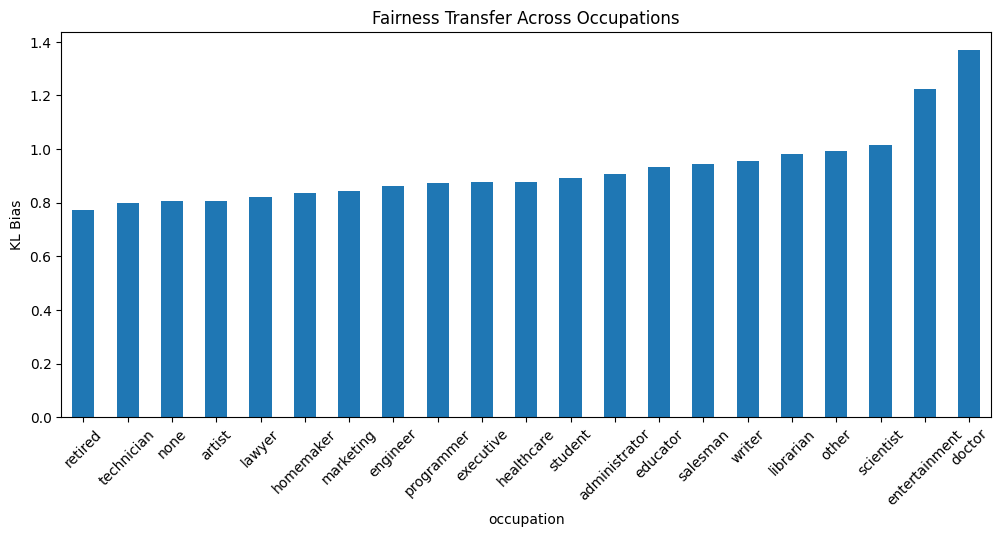

In [ ]:
# FAIRNESS GENERALIZATION TO OCCUPATION


# The 'rcp_df' DataFrame has already been merged with the 'users' DataFrame,
# and therefore already contains the 'occupation' column.
# We can directly use rcp_df for occupation evaluation.
occupation_eval = rcp_df

occupation_bias = occupation_eval.groupby("occupation").apply(
    lambda x: compute_bias(x)
)

print("=== Fairness Transfer Across Occupations ===")
print(occupation_bias.sort_values())

# Plot
plt.figure(figsize=(12,5))
occupation_bias.sort_values().plot(kind="bar")
plt.title("Fairness Transfer Across Occupations")
plt.ylabel("KL Bias")
plt.xticks(rotation=45)
plt.show()

     Group Type  Average Bias
0        Gender      0.917868
1           Age      0.920934
2    Occupation      0.922877
3  Gender × Age      0.921707


/tmp/ipykernel_3728/3267077010.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gender_bias = rcp_df.groupby("gender").apply(


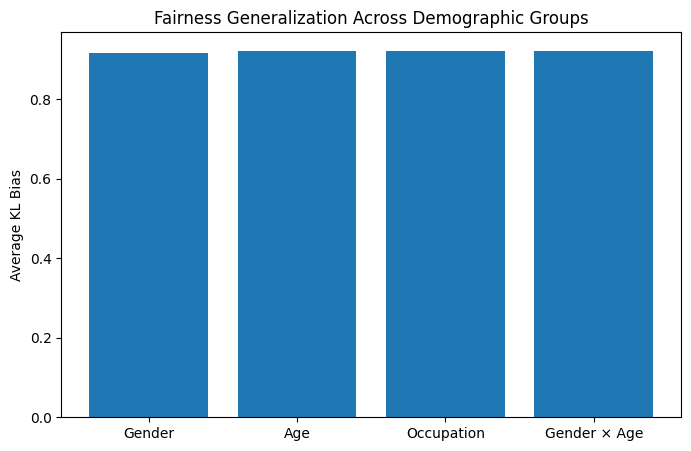

In [ ]:
# GLOBAL FAIRNESS COMPARISON


gender_bias = rcp_df.groupby("gender").apply(
    lambda x: compute_bias(x)
).mean()

age_bias_mean = age_bias.mean()

occupation_bias_mean = occupation_bias.mean()

intersection_bias_mean = intersection_results["Fair Bias"].mean()

summary_df = pd.DataFrame({
    "Group Type": [
        "Gender",
        "Age",
        "Occupation",
        "Gender × Age"
    ],
    "Average Bias": [
        gender_bias,
        age_bias_mean,
        occupation_bias_mean,
        intersection_bias_mean
    ]
})

print(summary_df)

# Plot
plt.figure(figsize=(8,5))
plt.bar(summary_df["Group Type"], summary_df["Average Bias"])

plt.title("Fairness Generalization Across Demographic Groups")
plt.ylabel("Average KL Bias")

plt.show()

/tmp/ipykernel_3728/2580057584.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gender_biases_series = rcp_df.groupby("gender").apply(lambda x: compute_bias(x))


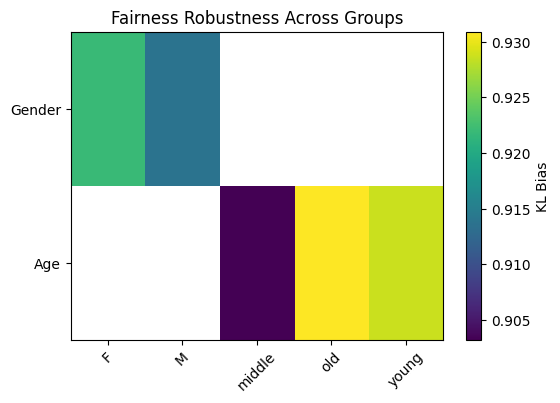

In [ ]:
# FAIRNESS ROBUSTNESS HEATMAP


# Calculate gender biases (Series with index 'F', 'M')
gender_biases_series = rcp_df.groupby("gender").apply(lambda x: compute_bias(x))

# age_bias is already a Series with index 'young', 'middle', 'old'
# Reindex ensures the order
age_biases_series = age_bias.reindex(["young","middle","old"])

# Create DataFrames from these Series, with appropriate column names
gender_df = pd.DataFrame({'Gender': gender_biases_series})
age_df = pd.DataFrame({'Age': age_biases_series})

# Merge these two DataFrames using an outer join to combine their indices.
# The result will have an index containing all unique categories (F, M, young, middle, old)
# and two columns ('Gender', 'Age'), with NaN where values don't apply.
heatmap_df = pd.merge(gender_df, age_df, left_index=True, right_index=True, how='outer')

plt.figure(figsize=(6,4))

# Transpose heatmap_df so 'Gender' and 'Age' become rows for imshow
plt.imshow(heatmap_df.T, aspect="auto")

plt.colorbar(label="KL Bias")

# Y-ticks will label the rows of the transposed matrix (Gender, Age)
plt.yticks([0,1], ["Gender","Age"])
# X-ticks will label the columns of the transposed matrix (all categories)
plt.xticks(range(len(heatmap_df.index)), heatmap_df.index, rotation=45)

plt.title("Fairness Robustness Across Groups")

plt.show()

In [ ]:
# OVERALL PROJECT SUMMARY
# Main Objective:

# The project builds a fairness-aware movie recommender system using collaborative filtering and fairness-aware re-ranking.

# Core Contributions:
    # (A) Matrix factorization recommendation model (SVD)
    # (B) Fairness-aware re-ranking
    # (C) Adaptive fairness weighting
    # (D) Intersectional fairness analysis
    # (E) Runtime optimization
    # (F) Robustness experiments
    # (G) Fairness generalization analysis

# Main Findings:
    # (A) Fairness-aware re-ranking reduces demographic bias.
    # (B) Recommendation quality remains relatively high.
    # (C) Adaptive fairness further improves personalization.
    # (D) Optimization drastically reduces runtime.
    # (E) Fairness improvements generalize across demographic groups.

# Key Metrics Used:
    # (A) HitRate (HR)
    # (B) NDCG
    # (C) KL-Divergence Bias
    # (D) Runtime Performance

# Final Takeaway:

# The project demonstrates that recommender systems can become significantly fairer while maintaining strong recommendation quality and computational efficiency.